In [1]:
# ставим относительный путь

from pathlib import Path
import os

os.chdir(Path("..").resolve())
print(Path.cwd())


/


In [2]:
# ставим конфиг

from src.dataset import RESDDataset
from src.plot import (
    plot_class_distribution,
    plot_duration_distribution,
    plot_log_mel_spectrogram,
    plot_mel_filter_bank,
    plot_spectrogram_db,
    set_plot_theme,
    show_spectrogram,
    show_waveform,
)
import torchaudio

from pathlib import Path
import os
from IPython.display import Audio

from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

set_plot_theme()

GlobalHydra.instance().clear()

with initialize_config_dir(
    version_base="1.3",
    config_dir="/Users/aleksandr/ser/speech-emo-recognition/configs",
):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))


ModuleNotFoundError: No module named 'src'

In [3]:
import os
from getpass import getpass

if not os.getenv("HF_TOKEN"):
    token = getpass("Enter HF token: ")
    if token:
        os.environ["HF_TOKEN"] = token

In [4]:
import os
print("HF_TOKEN set:", bool(os.getenv("HF_TOKEN")))

In [5]:
dataset = RESDDataset(split='train')

In [6]:
dataset[2]

(tensor([-9.1553e-05, -2.1362e-04, -9.1553e-05,  ...,  6.1035e-05,
          1.8311e-04,  2.4414e-04]),
 tensor(1))

In [7]:
wav = dataset[1][0]
label = dataset[1][1]
sr = dataset[1][2]

show_waveform(wav, label, sr=sr)
show_spectrogram(wav, label, sr=sr)
Audio(wav, rate=sr)

IndexError: tuple index out of range

In [9]:
from tqdm import tqdm

labels = []

for i in tqdm(range(len(dataset))):
    labels.append(dataset[i][2])

100%|██████████| 1116/1116 [00:16<00:00, 68.36it/s]


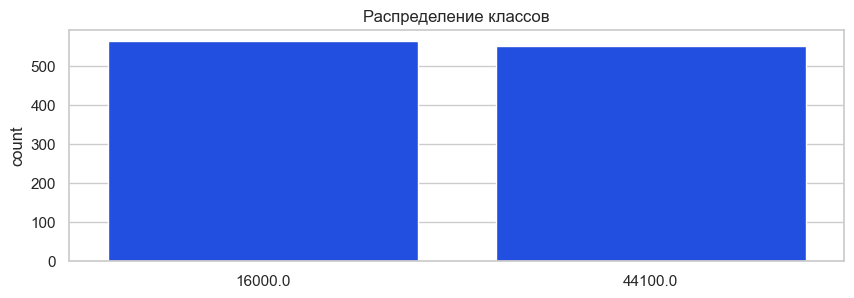

In [10]:
plot_class_distribution(labels)

In [11]:
from tqdm import tqdm

labels = []

for i in tqdm(range(len(dataset))):
    labels.append(dataset[i][1].item())

100%|██████████| 1116/1116 [00:16<00:00, 68.30it/s]


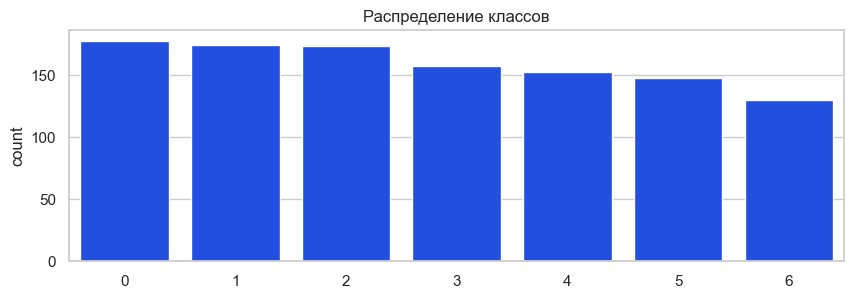

In [12]:
plot_class_distribution(labels)